# Emitter-Density Simulation — Image Generation

Generates 512×512 Bayer-camera images at 100 density levels (0.01–1 emitters/µm²)
for three dyes (ATTO 488, ATTO 565, ATTO 647N) and three photon levels (1000, 4000, 10 000).

Each (dye, n_photons, density) condition is saved as:
- A `(n_frames, 512, 512)` uint16 TIFF stack — independent noise realisations at that density
- A companion CSV with per-frame ground-truth emitter positions (x_px, y_px) and drawn photon counts

Save root: `/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/Simulation/20260630_S3MEmitterDensity/`

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import json
import time
import tifffile
from pathlib import Path

from pyS3M import IOFunctions, SpectralFunctions, MaskFunctions, PSFFunctions
from pyS3M.simulation.multicolour import MultiC_Sim_Funcs
from pyS3M import PlottingBase

IO  = IOFunctions.IO_Functions()
S_F = SpectralFunctions.Spectral_Funcs()
M_F = MaskFunctions.Mask_Functions()
PSF = PSFFunctions.PSF_Functions()
MSF = MultiC_Sim_Funcs()
plotter = PlottingBase.PublicationPlotter()

In [2]:
# ── Camera calibration ─────────────────────────────────────────────────────────
data_folder = '../../../Camera_Calibrations/Ximea_Camera/'
gain      = IO.read_tiff(os.path.join(data_folder, 'gain.tif'))
offset    = IO.read_tiff(os.path.join(data_folder, 'offset.tif'))
variance  = IO.read_tiff(os.path.join(data_folder, 'variance.tif'))
readnoise = float(np.median(IO.read_tiff(os.path.join(data_folder, 'readnoise.tif'))))
rqe       = IO.read_tiff(os.path.join(data_folder, 'rqe.tif'))

gain_val     = float(np.median(gain))
offset_val   = float(np.median(offset))
variance_val = float(np.median(variance))
print(f'gain={gain_val:.4f}  offset={offset_val:.2f}  variance={variance_val:.4f}  readnoise={readnoise:.2f}')

gain=0.4144  offset=32.35  variance=0.9374  readnoise=2.34


In [3]:
# ── Spectral setup ─────────────────────────────────────────────────────────────
R_base, G_base, B_base, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B_base, G_base, R_base])  # B=0, G=1, R=2
pixel_order = ['B', 'G', 'R']
filters = []

dyes   = ['ATTO 488', 'ATTO 565', 'ATTO 647N', 'synthetic_ATTO488', 'synthetic_ATTO565', 'synthetic_ATTO647N']
NA     = 1.49
pixel_size = 69.0   # nm/pixel

In [4]:
# ── Simulation parameters ──────────────────────────────────────────────────────
image_size     = 512          # pixels (square)
n_frames       = 1000         # frames (realisations) per TIFF stack
bg_per_pixel   = 10.0          # background photoelectrons per pixel per frame

n_density_steps = 100
density_min     = 0.01        # emitters / µm²
density_max     = 1        # emitters / µm²
density_space   = np.linspace(density_min, density_max, n_density_steps)

n_photon_levels = [1000, 4000, 10_000]

# Image area in µm²
pixel_size_um   = pixel_size * 1e-3   # µm
image_area_um2  = (image_size * pixel_size_um) ** 2

print(f'Image: {image_size}×{image_size} px  ({image_size * pixel_size_um:.2f} µm × {image_size * pixel_size_um:.2f} µm)')
print(f'Image area: {image_area_um2:.1f} µm²')
print(f'Density range: {density_min}–{density_max} / µm²  ({n_density_steps} steps)')
print(f'N emitters at min/max density: {int(round(density_min * image_area_um2))} – {int(round(density_max * image_area_um2))}')
print(f'n_frames per stack: {n_frames}')
print(f'Total stacks: {len(density_space) * len(n_photon_levels) * len(dyes)} '
      f'({len(density_space)} densities × {len(n_photon_levels)} photon levels × {len(dyes)} dyes)')
total_gb = (
    n_density_steps * len(n_photon_levels) * len(dyes)
    * n_frames * image_size * image_size * 2 / 1e9
)
print(f'Estimated image data: {total_gb:.1f} GB')

Image: 512×512 px  (35.33 µm × 35.33 µm)
Image area: 1248.1 µm²
Density range: 0.01–1 / µm²  (100 steps)
N emitters at min/max density: 12 – 1248
n_frames per stack: 1000
Total stacks: 1800 (100 densities × 3 photon levels × 6 dyes)
Estimated image data: 943.7 GB


In [5]:
# ── 512×512 Bayer masks ────────────────────────────────────────────────────────
masks_512 = M_F.get_masks(size_x=image_size, size_y=image_size)
print('Mask channels:', list(masks_512.keys()))
for ch, m in masks_512.items():
    print(f'  {ch}: {m.sum()} True pixels  ({100 * m.mean():.1f}%)')

Mask channels: ['B', 'G', 'R']
  B: 65536 True pixels  (25.0%)
  G: 131072 True pixels  (50.0%)
  R: 65536 True pixels  (25.0%)


In [6]:
# ── Save folder ────────────────────────────────────────────────────────────────
save_root = Path('/scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/Simulation/20260630_S3MEmitterDensity')
save_root.mkdir(parents=True, exist_ok=True)
print(f'Saving to: {save_root}')

Saving to: /scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/Simulation/20260630_S3MEmitterDensity


In [7]:
# ── camera_calibration dict for gen_camera_image_stack ────────────────────────
# Crop calibration maps to image_size × image_size; gen_camera_image_stack
# derives the output image dimensions from gain.shape.
cam_gain     = gain[:image_size, :image_size].astype(np.float64)
cam_offset   = offset[:image_size, :image_size].astype(np.float64)
cam_variance = variance[:image_size, :image_size].astype(np.float64)
cam_rqe      = rqe[:image_size, :image_size].astype(np.float64)

camera_calibration_512 = {
    'gain':        cam_gain,
    'offset':      cam_offset,
    'variance':    cam_variance,
    'rqe':         cam_rqe,
    'pixel_QYs':   pixel_QYs,   # (n_channels, n_wavelengths) — required by _validate_inputs
    'pixel_order': pixel_order,
    'masks':       masks_512,
}
print(f'camera_calibration_512: {cam_gain.shape}  '
      f'gain_med={np.median(cam_gain):.4f}  offset_med={np.median(cam_offset):.2f}')

camera_calibration_512: (512, 512)  gain_med=0.4114  offset_med=32.34


In [11]:
# ── Pre-compute per-dye spectral parameters ────────────────────────────────────
# dpe_arr: raw (un-normalised) dye-pixel efficiency — used directly as Binomial
# probability p in gen_camera_image_stack (Binomial(photons_at_pixel, dpe[ch])).
#
# 'synthetic_<DYE>' entries model a hypothetical camera with the *same* PSF size
# as <DYE> (same aew -> same sigma_px, reused directly from <DYE>'s own entry
# below rather than recomputed) but with every pixel sharing Prime95B's QE --
# i.e. no Bayer colour discrimination -- instead of Ximea's per-channel QE, to
# isolate pure PSF-size effects from spectral/colour ones. QE curve:
# Spectra/Camera_QE/Prime95B.csv -- two columns, no header, (wavelength_nm,
# QE_percent); interpolated onto the same wavelength grid Ximea uses, /100 for
# a 0-1 fraction (same convention as FigureSI_XimeavsPrime95B.ipynb). The
# absolute QE integral (normalized=False) is used here, not normalized=True as
# for the real dyes above -- feeding an identical curve into every "channel"
# row under normalized=True collapses to 1/3 for *any* curve by symmetry
# (the per-wavelength ratio QE(λ)/[3·QE(λ)] = 1/3 regardless of QE(λ) itself),
# which would make Prime95B's actual QE irrelevant; normalized=False instead
# gives a genuine, dye-dependent absolute efficiency.
p95b_raw    = np.loadtxt('../../../Spectra/Camera_QE/Prime95B.csv', delimiter=',')
prime95b_qe = np.interp(wavelength, p95b_raw[:, 0], p95b_raw[:, 1] / 100.0)

SYNTHETIC_SOURCE_DYE = {
    'synthetic_ATTO488':  'ATTO 488',
    'synthetic_ATTO565':  'ATTO 565',
    'synthetic_ATTO647N': 'ATTO 647N',
}

dye_params = {}
for dye in dyes:
    if dye in SYNTHETIC_SOURCE_DYE:
        source_dye = SYNTHETIC_SOURCE_DYE[dye]
        aew = dye_params[source_dye]['aew_nm']  # same PSF size as the source dye
        _, abs_qe = S_F.get_pixel_fractions_dye_and_filters(
            [source_dye], filters, wavelength, prime95b_qe[np.newaxis, :], normalized=False
        )
        dpe_arr = np.full(3, float(np.ravel(abs_qe)[0]))  # same QE at every pixel
    else:
        aew, dpe_raw = S_F.get_pixel_fractions_dye_and_filters(
            [dye], filters, wavelength, pixel_QYs
        )
        aew     = float(aew)
        dpe_arr = np.array(dpe_raw).ravel()          # raw per-channel efficiency

    sigma_px = PSF.sigma_PSF(float(aew), NA) / pixel_size
    dye_params[dye] = {'dpe': dpe_arr, 'sigma_px': sigma_px, 'aew_nm': float(aew)}
    print(f'{dye:20s}  aew={float(aew):.0f} nm  sigma={sigma_px:.3f} px  dpe={np.round(dpe_arr, 3)}')

ATTO 488              aew=539 nm  sigma=1.180 px  dpe=[ 0.139  0.751  0.11 ]
ATTO 565              aew=612 nm  sigma=1.340 px  dpe=[ 0.03   0.387  0.584]
ATTO 647N             aew=685 nm  sigma=1.501 px  dpe=[ 0.065  0.214  0.721]
synthetic_ATTO488     aew=539 nm  sigma=1.180 px  dpe=[ 0.94  0.94  0.94]
synthetic_ATTO565     aew=612 nm  sigma=1.340 px  dpe=[ 0.928  0.928  0.928]
synthetic_ATTO647N    aew=685 nm  sigma=1.501 px  dpe=[ 0.851  0.851  0.851]


In [12]:
# ── Save metadata ──────────────────────────────────────────────────────────────
meta = {
    'image_size':       image_size,
    'pixel_size_nm':    pixel_size,
    'NA':               NA,
    'n_frames':         n_frames,
    'bg_per_pixel':     bg_per_pixel,
    'density_space':    density_space.tolist(),
    'n_photon_levels':  n_photon_levels,
    'dyes':             dyes,
    'pixel_order':      pixel_order,
    'image_area_um2':   image_area_um2,
    'gain_val':         gain_val,
    'offset_val':       offset_val,
    'variance_val':     variance_val,
    'readnoise':        readnoise,
    'dye_params':       {
        d: {
            'dpe':      dye_params[d]['dpe'].tolist(),
            'sigma_px': dye_params[d]['sigma_px'],
            'aew_nm':   dye_params[d]['aew_nm'],
        }
        for d in dyes
    },
}
(save_root / 'metadata.json').write_text(json.dumps(meta, indent=2))
print(f'Saved metadata → {save_root / "metadata.json"}')

Saved metadata → /scratch/sycamore-asap/ASAP_Members_Other_Imaging_Data/JSB/Simulation/20260630_S3MEmitterDensity/metadata.json


In [13]:
# ── Main simulation loop ───────────────────────────────────────────────────────
#
# For each (dye, n_photons, density):
#   • generate n_frames independent 512×512 Bayer images via gen_camera_image_stack
#   • save as a (n_frames, 512, 512) uint16 TIFF stack
#   • save companion ground-truth CSV: frame_idx, emitter_id, x_px, y_px, n_photons
#
# Frames are generated in batches of BATCH to keep peak memory under ~1 GB.
# Each batch call: (BATCH, 512, 512) int64 × 2 intermediate arrays ≈ 400 MB.

BATCH = 2000

n_total_cond = len(dyes) * len(n_photon_levels) * len(density_space)
i_cond       = 0
t0_total     = time.time()

for dye in dyes:
    dye_str = dye.replace(' ', '_')
    dp      = dye_params[dye]
    dpe     = dp['dpe']
    aew_nm  = dp['aew_nm']

    for n_photon in n_photon_levels:
        ph_dir = save_root / dye_str / f'{n_photon}ph'
        ph_dir.mkdir(parents=True, exist_ok=True)

        for d_idx, density in enumerate(density_space):
            i_cond     += 1
            N_emitters  = max(1, int(round(density * image_area_um2)))

            stem     = f'd{d_idx:02d}_density{density:.4f}'
            tif_path = ph_dir / f'{stem}_images.tif'
            gt_path  = ph_dir / f'{stem}_gt.csv'

            if tif_path.exists() and gt_path.exists():
                print(f'[{i_cond:4d}/{n_total_cond}] {dye:12s}  {n_photon:6d}ph  '
                      f'd{d_idx:02d}  N={N_emitters:4d}  (skipped)')
                continue

            t0_cond = time.time()
            gt_rows = []

            with tifffile.TiffWriter(tif_path, bigtiff=True) as tif:
                for b_start in range(0, n_frames, BATCH):
                    b_end  = min(n_frames, b_start + BATCH)
                    b_size = b_end - b_start

                    # Random emitter positions in nm for this batch
                    x_nm = np.random.uniform(0.0, image_size * pixel_size, (b_size, N_emitters))
                    y_nm = np.random.uniform(0.0, image_size * pixel_size, (b_size, N_emitters))
                    # x0y0[dye]: (b_size, 2, N_emitters) — positions in nm
                    x0y0_batch = {dye: np.stack([x_nm, y_nm], axis=1)}

                    bayer_batch, _, _ = MSF.gen_camera_image_stack(
                        camera_calibration_512,
                        wavelength,
                        aew_nm,
                        dpe,
                        {dye: np.full(b_size, float(n_photon))},
                        x0y0_batch,
                        smoothing_function=None,
                        background_photons=bg_per_pixel,
                        background_colour=[1.0] * len(pixel_order),
                        NA=NA,
                        pixel_size=pixel_size,
                    )
                    # gen_camera_image_stack squeezes size-1 dims; reshape defensively
                    bayer_batch = np.asarray(bayer_batch).reshape(b_size, image_size, image_size)

                    for frame_img in bayer_batch:
                        tif.write(frame_img.astype(np.uint16), contiguous=True)

                    for fi in range(b_size):
                        for em_id in range(N_emitters):
                            gt_rows.append({
                                'frame_idx':  b_start + fi,
                                'emitter_id': em_id,
                                'x_px':       float(x_nm[fi, em_id] / pixel_size),
                                'y_px':       float(y_nm[fi, em_id] / pixel_size),
                                'n_photons':  n_photon,
                            })

            pd.DataFrame(gt_rows).to_csv(gt_path, index=False)

            elapsed   = time.time() - t0_cond
            t_elapsed = (time.time() - t0_total) / 60
            t_remain  = (n_total_cond - i_cond) * elapsed / 60
            print(f'[{i_cond:4d}/{n_total_cond}] {dye:12s}  {n_photon:6d}ph  '
                  f'd{d_idx:02d}  N={N_emitters:4d}  '
                  f'{elapsed:.1f}s  elapsed={t_elapsed:.1f}m  ETA={t_remain:.1f}m')

print(f'\nAll done in {(time.time() - t0_total) / 60:.1f} min.')

[   1/1800] ATTO 488        1000ph  d00  N=  12  (skipped)
[   2/1800] ATTO 488        1000ph  d01  N=  25  (skipped)
[   3/1800] ATTO 488        1000ph  d02  N=  37  (skipped)
[   4/1800] ATTO 488        1000ph  d03  N=  50  (skipped)
[   5/1800] ATTO 488        1000ph  d04  N=  62  (skipped)
[   6/1800] ATTO 488        1000ph  d05  N=  75  (skipped)
[   7/1800] ATTO 488        1000ph  d06  N=  87  (skipped)
[   8/1800] ATTO 488        1000ph  d07  N= 100  (skipped)
[   9/1800] ATTO 488        1000ph  d08  N= 112  (skipped)
[  10/1800] ATTO 488        1000ph  d09  N= 125  (skipped)
[  11/1800] ATTO 488        1000ph  d10  N= 137  (skipped)
[  12/1800] ATTO 488        1000ph  d11  N= 150  (skipped)
[  13/1800] ATTO 488        1000ph  d12  N= 162  (skipped)
[  14/1800] ATTO 488        1000ph  d13  N= 175  (skipped)
[  15/1800] ATTO 488        1000ph  d14  N= 187  (skipped)
[  16/1800] ATTO 488        1000ph  d15  N= 200  (skipped)
[  17/1800] ATTO 488        1000ph  d16  N= 212  (skippe

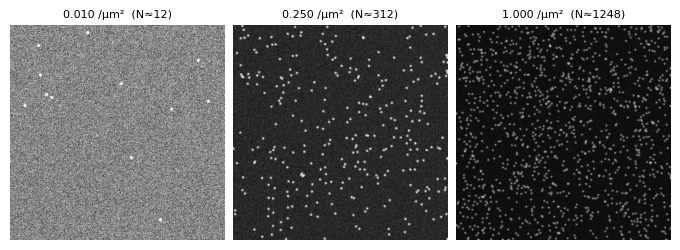

In [18]:
# ── Quick visual check: sample images at low, mid, high density ───────────────
check_dye      = 'ATTO 647N'
check_n_photon = 4000
check_frame    = 0
check_d_idxs   = [0, 24, 99]   # first, middle, last density

fig, axs = plotter.two_column_plot(ncols=3)

for ax, d_idx in zip(axs, check_d_idxs):
    density = density_space[d_idx]
    tif_path = (
        save_root
        / check_dye.replace(' ', '_')
        / f'{check_n_photon}ph'
        / f'd{d_idx:02d}_density{density:.4f}_images.tif'
    )
    if not tif_path.exists():
        ax.set_title(f'Missing: d{d_idx:02d}', fontsize=8)
        ax.axis('off')
        continue

    with tifffile.TiffFile(tif_path) as tif:
        frame = tif.pages[check_frame].asarray()

    n_em = max(1, int(round(density * image_area_um2)))
    vmin, vmax = np.percentile(frame, [1, 99])
    ax.imshow(frame, cmap='gray', vmin=vmin, vmax=vmax, origin='upper')
    ax.set_title(
        f'{density:.3f} /µm²  (N≈{n_em})', fontsize=8
    )
    ax.axis('off')

fig_save_folder = '/scratch/sycamore-asap/2026_Multicolour_Paper/For_Paper'
plt.savefig(os.path.join(fig_save_folder, check_dye+'_density_examples.svg'), format='svg', dpi=600)
plt.show()

## Spot Detection + Fitting

Detect spots in each simulated TIFF stack at two pfa thresholds, fit Gaussian PSFs, and save localizations to per-condition H5 files.

In [14]:

# ── Analysis pipeline for spot detection + fitting ─────────────────────────────
from pyS3M.AnalysisPipeline import AnalysisPipeline
# Bare import (not `from src.ImageAnalysisFunctions import ...`): AnalysisPipeline/
# SR_Functions add src/ to sys.path and bare-import ImageAnalysisFunctions internally.
# Importing via the `src.` package path registers a second, distinct module under
# sys.modules['src.ImageAnalysisFunctions'], giving a FittingStrategy Enum class that
# is not the one FittingConstants.PARAM_DIMENSIONS is keyed on -> spurious KeyError.
from pyS3M.ImageAnalysisFunctions import FittingStrategy
from pyS3M.Constants import ResultColumns
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

pipe = AnalysisPipeline(camera='ximea', pixel_size=pixel_size_um)
pipe.load_calibration(data_folder)
SR_F = pipe.sr                     # SuperRes_Functions instance
sf   = pipe.make_smoothing_function(sigma=1.5)

# Calibration maps cropped to image_size (reuse from edd-0007)
gain_512   = cam_gain.astype(np.float32)
offset_512 = cam_offset.astype(np.float32)
var_512    = cam_variance.astype(np.float32)
rqe_512    = cam_rqe.astype(np.float32)
rn_512     = pipe.read_noise[:image_size, :image_size].astype(np.float32)

# Stacked Bayer masks: shape (height, width, n_channels)
masks_stacked = M_F.get_stacked_masks(0, 0, image_size, image_size)

result_params  = ResultColumns.get_all_columns()

# 'synthetic_' dyes carry no real R/G/B signal difference (dye_params[dye]['dpe'] is
# uniform across channels -- see edd-0008), so they're fit with FittingStrategy.NOCOLOUR
# (intensity-only, no colour channels) rather than STANDARD_DATA. NOCOLOUR's own output
# shape ({"fit": 8, "error": 6}, per FittingConstants.PARAM_DIMENSIONS) doesn't match
# ResultColumns.get_all_columns() (built for STANDARD_DATA's per-channel columns), so it
# needs its own column list here -- verified empirically against a real NOCOLOUR fit
# (fit_arr = [xc, yc, s_x, s_y, bg, A, chi_sqr, frame], err_arr = the first 6 of those
# with '_err' suffixed) rather than assumed from the docstrings alone.
result_params_nocolour = [
    'xc', 'yc', 's_x', 's_y', 'bg', 'A', 'chi_sqr', 'frame',
    'xc_err', 'yc_err', 's_x_err', 's_y_err', 'bg_err', 'A_err',
]

pfa_conditions = [1e-3, 1e-4]
ROI_size       = 16

def pfa_tag(pfa):
    return f'pfa{pfa:.0e}'.replace('e-0', 'e-')

print('result_params:', result_params[:6], '...')
print('result_params_nocolour:', result_params_nocolour)
print('pfa_tags:', [pfa_tag(p) for p in pfa_conditions])
print('masks_stacked:', masks_stacked.shape)


/home/jsb92/Documents/venv/lib/python3.12/site-packages/fast_hdbscan/numba_kdtree.py:218: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  return deheap_sort(result[0], result[1])
INFO:pyS3M.AnalysisPipeline:AnalysisPipeline initialised (camera=ximea, pixel_size=0.0690 µm)
INFO:pyS3M.AnalysisPipeline:Calibration loaded from ../../../Camera_Calibrations/Ximea_Camera


result_params: ['xc', 'yc', 's_x', 's_y', 'bg_B', 'bg_G'] ...
result_params_nocolour: ['xc', 'yc', 's_x', 's_y', 'bg', 'A', 'chi_sqr', 'frame', 'xc_err', 'yc_err', 's_x_err', 's_y_err', 'bg_err', 'A_err']
pfa_tags: ['pfa1e-3', 'pfa1e-4']
masks_stacked: (512, 512, 3)


bilinear    d00  density=0.0100/um^2  frame=0: 12 true emitters, 30 spots detected (detected - true = +18)
bilinear    d99  density=1.0000/um^2  frame=0: 1248 true emitters, 750 spots detected (detected - true = -498)
malvar      d00  density=0.0100/um^2  frame=0: 12 true emitters, 32 spots detected (detected - true = +20)
malvar      d99  density=1.0000/um^2  frame=0: 1248 true emitters, 831 spots detected (detected - true = -417)
menon2007   d00  density=0.0100/um^2  frame=0: 12 true emitters, 29 spots detected (detected - true = +17)
menon2007   d99  density=1.0000/um^2  frame=0: 1248 true emitters, 851 spots detected (detected - true = -397)


/tmp/ipykernel_505074/135888943.py:94: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


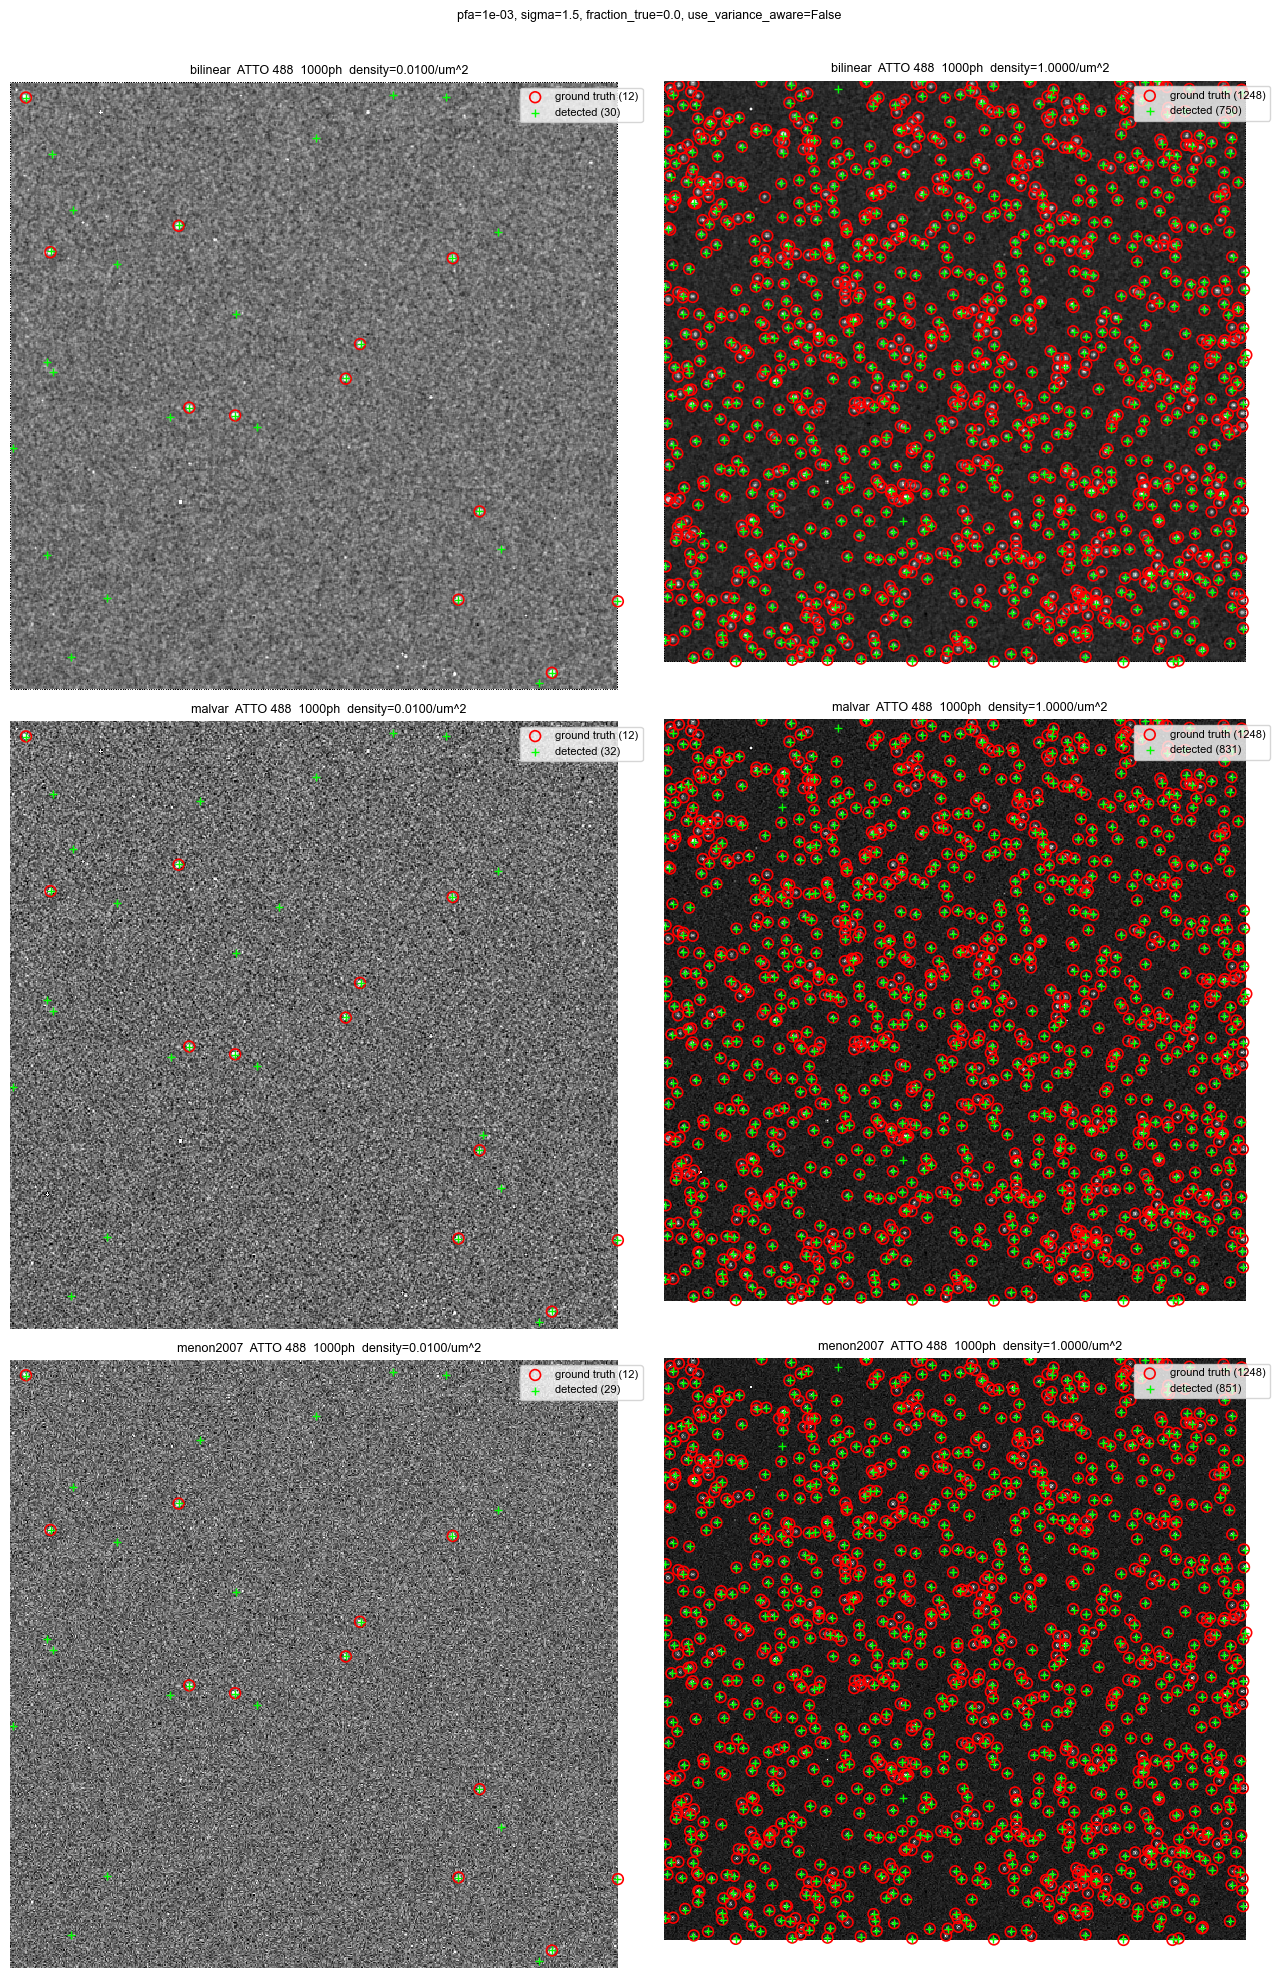

In [15]:
# ── Spot detection preview — tune sigma/pfa/demosaic strategy before the full loop ──
# Diagnose whether "too many spots are being found" at low density: since this
# is simulated data, exact ground-truth emitter positions are known (the
# '{stem}_gt.csv' files from the generation loop above), so detected spots can
# be overlaid directly against ground truth rather than judged by eye alone.
#
# use_variance_aware=False here: variance-aware demosaicing rescales every
# pixel by 1/variance_pe (src/sCMOSFunctions.py:196-202) before interpolating,
# which amplifies any near-zero/noisy entries in the *measured* variance
# calibration map into large weight spikes — distorting both signal and noise
# in a way that a simple propagated-variance correction can't fully undo
# (confirmed empirically: far more spurious low-density detections with
# use_variance_aware=True, even after Monte Carlo-propagating the true
# post-reweighting variance, than with use_variance_aware=False). This only
# affects where spots are detected — the actual fit re-extracts photoelectron
# data straight from the raw Bayer frame regardless (see the full loop below),
# so nothing about final measurement fidelity is lost by using the simpler
# image for detection.
#
# Also compares demosaic STRATEGY (now exposed via SR_Functions._demosaic_image's
# new `strategy` kwarg) at the same time, since a different interpolation
# algorithm could also affect how well true spots are separated from noise.
#
# Shows every (strategy x density) combination, one frame each, at the lowest
# and highest simulated density.

PFA_PREVIEW           = 1e-3
SIGMA_PREVIEW         = 1.5    # SpotDetectionFunctions' detection-threshold sigma
                                # (background-threshold multiplier — NOT the PSF sigma)
FRACTION_TRUE_PREVIEW = 0.0
PREVIEW_FRAME         = 0
PREVIEW_STRATEGIES    = ['bilinear', 'malvar', 'menon2007']

preview_dye      = dyes[0]
preview_n_photon = n_photon_levels[0]
preview_d_idxs   = [0, len(density_space) - 1]   # lowest, highest density


def _load_and_detect(d_idx, strategy):
    density  = density_space[d_idx]
    dye_str  = preview_dye.replace(' ', '_')
    aew_um   = dye_params[preview_dye]['aew_nm'] / 1000.0
    ph_dir   = save_root / dye_str / f'{preview_n_photon}ph'
    stem     = f'd{d_idx:02d}_density{density:.4f}'
    tif_path = ph_dir / f'{stem}_images.tif'
    gt_path  = ph_dir / f'{stem}_gt.csv'

    frame_raw = IO.read_tiff(str(tif_path), frame=PREVIEW_FRAME, dtype='float32')
    if frame_raw.ndim == 2:
        frame_raw = frame_raw[np.newaxis]

    img_detect = SR_F._demosaic_image(frame_raw, use_variance_aware=False, strategy=strategy)
    img_detect_2d = img_detect[0] if img_detect.ndim == 3 else img_detect

    detected = SR_F.spot_detection.detect_puncta_in_image(
        img_detect_2d,
        pfa=PFA_PREVIEW, variance=var_512, wavelength=aew_um,
        pixel_size=pixel_size_um, NA=NA, sigma=SIGMA_PREVIEW,
        fraction_true=FRACTION_TRUE_PREVIEW,
    )

    gt_df    = pd.read_csv(gt_path)
    gt_frame = gt_df[gt_df['frame_idx'] == PREVIEW_FRAME]

    return density, img_detect_2d, detected, gt_frame


fig, axs = plt.subplots(len(PREVIEW_STRATEGIES), len(preview_d_idxs),
                         figsize=(6.5 * len(preview_d_idxs), 6.5 * len(PREVIEW_STRATEGIES)),
                         squeeze=False)
for row, strategy in enumerate(PREVIEW_STRATEGIES):
    for col, d_idx in enumerate(preview_d_idxs):
        ax = axs[row, col]
        density, img_detect_2d, detected, gt_frame = _load_and_detect(d_idx, strategy)

        n_fp_ish = len(detected) - len(gt_frame)
        print(f'{strategy:10s}  d{d_idx:02d}  density={density:.4f}/um^2  frame={PREVIEW_FRAME}: '
              f'{len(gt_frame)} true emitters, {len(detected)} spots detected '
              f'(detected - true = {n_fp_ish:+d})')

        vmin, vmax = np.percentile(img_detect_2d, [0.1, 99.9])
        ax.imshow(img_detect_2d, cmap='gray', vmin=vmin, vmax=vmax, origin='upper', interpolation='nearest')
        ax.scatter(gt_frame['y_px'], gt_frame['x_px'], s=60, facecolors='none', edgecolors='red',
                   linewidths=1.2, label=f'ground truth ({len(gt_frame)})')
        if len(detected):
            ax.scatter(detected[:, 1], detected[:, 0], s=30, marker='+', color='lime', linewidths=1.0,
                       label=f'detected ({len(detected)})')
        ax.legend(loc='upper right', fontsize=8)
        ax.set_title(f'{strategy}  {preview_dye}  {preview_n_photon}ph  density={density:.4f}/um^2', fontsize=9)
        ax.axis('off')

plt.suptitle(f'pfa={PFA_PREVIEW:.0e}, sigma={SIGMA_PREVIEW}, fraction_true={FRACTION_TRUE_PREVIEW}, use_variance_aware=False',
             fontsize=9, y=1.01)
plt.tight_layout()
plt.show()

In [16]:
# ── Spot detection + fitting loop ──────────────────────────────────────────────
#
# Sweeps three detection-strategy parameters per (dye, n_photon, density)
# condition, so downstream metrics can be compared against one another as a
# function of density to find the best spot-detection strategy:
#   - demosaic STRATEGY (bilinear / malvar / menon2007 / none)
#   - PFA (1e-3, 1e-4)
#   - fraction_true (0, 0.1, 0.2, 0.5)
#
# 'none' skips demosaicing entirely -- detection runs directly on the raw
# Bayer-mosaic stack (same convention as FigureSI_ExampleAnalysisWorkflow.ipynb's
# no-demosaic pipeline: `detect_puncta_in_stack_parallel` and
# `_process_detected_puncta_batch` both just take an image/stack array and don't
# care whether it's been demosaiced, since the variance-divide "whitening" step
# happens internally regardless).
#
# The raw TIFF is loaded once per (dye, n_photon, density) condition, and each
# demosaic strategy is computed once and reused across every (pfa,
# fraction_true) combination for that strategy -- demosaicing doesn't depend on
# either, so this avoids redoing the most expensive step 8x per condition.
#
# OVERWRITE=False (default): before doing any work for a given strategy, check
# whether every (pfa, fraction_true) H5 file for that strategy already exists;
# if so, skip that strategy's demosaic + detect + fit work entirely rather than
# just skipping the inner fit call file-by-file. This means a crash partway
# through the sweep only costs re-demosaicing the strategies that weren't
# fully finished, not every strategy for that condition.
#
# NOTE: 4 strategies x 2 pfa x 4 fraction_true = 32 fits per condition, and
# 3 dyes x 3 photon levels x 50 densities conditions -> 14,400 H5 files total.
# This is a large sweep; expect it to take substantially longer than the
# previous 2-pfa-only loop.

OVERWRITE = False

DEMOSAIC_STRATEGIES      = ['none']
FRACTION_TRUE_CONDITIONS = [0.0]


def condition_tag(strategy, pfa, fraction_true):
    return f'{strategy}_{pfa_tag(pfa)}_ft{fraction_true:.2f}'.replace('.', 'p')


n_total = (len(dyes) * len(n_photon_levels) * len(density_space)
           * len(DEMOSAIC_STRATEGIES) * len(pfa_conditions) * len(FRACTION_TRUE_CONDITIONS))
i_cond  = 0
t0_loop = time.time()

for dye in dyes:
    dye_str = dye.replace(' ', '_')
    aew_um  = dye_params[dye]['aew_nm'] / 1000.0   # wavelength in µm for detection

    for n_photon in n_photon_levels:
        ph_dir = save_root / dye_str / f'{n_photon}ph'

        for d_idx, density in enumerate(density_space):
            stem     = f'd{d_idx:02d}_density{density:.4f}'
            tif_path = ph_dir / f'{stem}_images.tif'

            h5_paths = {
                (strategy, pfa, ft): ph_dir / f'{stem}_{condition_tag(strategy, pfa, ft)}.h5'
                for strategy in DEMOSAIC_STRATEGIES
                for pfa in pfa_conditions
                for ft in FRACTION_TRUE_CONDITIONS
            }
            i_cond += len(h5_paths)

            if not OVERWRITE and all(p.exists() for p in h5_paths.values()):
                print(f'[{i_cond:5d}/{n_total}] {dye}  {n_photon}ph  d{d_idx:02d}  (skipped, all done)')
                continue

            t0c = time.time()

            # Load TIFF once
            raw = IO.read_tiff(str(tif_path), dtype='float32')   # (n_frames, H, W)
            if raw.ndim == 2:
                raw = raw[np.newaxis]

            for strategy in DEMOSAIC_STRATEGIES:
                strategy_h5_paths = {
                    (pfa, ft): h5_paths[(strategy, pfa, ft)]
                    for pfa in pfa_conditions
                    for ft in FRACTION_TRUE_CONDITIONS
                }
                if not OVERWRITE and all(p.exists() for p in strategy_h5_paths.values()):
                    # Every (pfa, fraction_true) combo for this strategy is already
                    # done -- skip demosaicing/detecting/fitting for it entirely.
                    continue

                img_detect = (
                    raw if strategy == 'none'
                    else SR_F._demosaic_image(raw, use_variance_aware=False, strategy=strategy)
                )

                for pfa in pfa_conditions:
                    for ft in FRACTION_TRUE_CONDITIONS:
                        h5_path = h5_paths[(strategy, pfa, ft)]
                        if not OVERWRITE and h5_path.exists():
                            continue

                        detected, quality = SR_F.spot_detection.detect_puncta_in_stack_parallel(
                            img_detect,
                            pfa=pfa, variance=var_512, wavelength=aew_um,
                            pixel_size=pixel_size_um, NA=NA, sigma=1.5,
                            fraction_true=ft, return_quality=True,
                        )

                        (puncta, smoothed, mask_rois, weights, coords, planes, qm
                         ) = SR_F._process_detected_puncta_batch(
                            raw, detected, image_size, image_size, ROI_size,
                            sf, rn_512, masks_stacked,
                            gain_map=gain_512, offset_map=offset_512, rqe=rqe_512,
                            frame_offset=0, is_multi_frame=True, quality_metrics=quality,
                        )

                        # synthetic_* dyes have no real per-channel signal difference
                        # (dye_params[dye]['dpe'] is uniform across channels -- edd-0008),
                        # so fit intensity-only (NOCOLOUR) rather than STANDARD_DATA; masks
                        # aren't used by NOCOLOUR fitting at all (colour-blind by design).
                        is_synthetic = dye in SYNTHETIC_SOURCE_DYE

                        if len(puncta) == 0:
                            fit_df = pd.DataFrame(
                                columns=result_params_nocolour if is_synthetic else result_params
                            )
                        elif is_synthetic:
                            fit_arr, err_arr = SR_F.image_analysis.fit_puncta_parallel_method(
                                puncta, smoothed, weights, coords, planes,
                                FittingStrategy.NOCOLOUR,
                            )
                            fit_df = SR_F._postprocess_fit_results(
                                fit_arr, err_arr, result_params_nocolour, planes,
                                image_size, image_size, quality_metrics=qm,
                            )
                        else:
                            fit_arr, err_arr = SR_F.image_analysis.fit_puncta_parallel_method(
                                puncta, smoothed, weights, coords, planes,
                                FittingStrategy.STANDARD_DATA, masks=mask_rois,
                            )
                            fit_df = SR_F._postprocess_fit_results(
                                fit_arr, err_arr, result_params, planes,
                                image_size, image_size, quality_metrics=qm,
                            )

                        IO.write_h5_database(fit_df, str(h5_path), normalise_photons=True)

            elapsed = time.time() - t0c
            t_left  = (n_total - i_cond) * (elapsed / len(h5_paths)) / 60
            print(f'[{i_cond:5d}/{n_total}] {dye}  {n_photon}ph  d{d_idx:02d}  '
                  f'{elapsed:.1f}s ({len(h5_paths)} combos)  ETA={t_left:.0f}m')

print(f'\nFitting done in {(time.time() - t0_loop) / 60:.1f} min')

[    2/3600] ATTO 488  1000ph  d00  (skipped, all done)
[    4/3600] ATTO 488  1000ph  d01  (skipped, all done)
[    6/3600] ATTO 488  1000ph  d02  (skipped, all done)
[    8/3600] ATTO 488  1000ph  d03  (skipped, all done)
[   10/3600] ATTO 488  1000ph  d04  (skipped, all done)
[   12/3600] ATTO 488  1000ph  d05  (skipped, all done)
[   14/3600] ATTO 488  1000ph  d06  (skipped, all done)
[   16/3600] ATTO 488  1000ph  d07  (skipped, all done)
[   18/3600] ATTO 488  1000ph  d08  (skipped, all done)
[   20/3600] ATTO 488  1000ph  d09  (skipped, all done)
[   22/3600] ATTO 488  1000ph  d10  (skipped, all done)
[   24/3600] ATTO 488  1000ph  d11  (skipped, all done)
[   26/3600] ATTO 488  1000ph  d12  (skipped, all done)
[   28/3600] ATTO 488  1000ph  d13  (skipped, all done)
[   30/3600] ATTO 488  1000ph  d14  (skipped, all done)
[   32/3600] ATTO 488  1000ph  d15  (skipped, all done)
[   34/3600] ATTO 488  1000ph  d16  (skipped, all done)
[   36/3600] ATTO 488  1000ph  d17  (skipped, al

## Performance Metrics

Compare ground-truth emitter positions against fitted localizations via optimal 1:1 Hungarian matching within a radius of `match_multiplier × sigma_PSF` (or `× mean_loc_error`).  Metrics per condition: Jaccard index, PPV (precision), Recall, FP-rate, missed-rate.

**Axis-swap fix:** an earlier version of this cell compared the ground-truth
`(x_px, y_px)` directly against the fitted `(xc, yc)`, which produced anomalously
low recall/PPV/Jaccard (recall maxing out around 0.02-0.03) even though detections
visually lined up with the true emitters. Root cause: `gen_camera_image_stack`
places the emitter's `x0` along the image array's axis 0 ("row") and `y0` along
axis 1 ("col"), while the detection/fitting pipeline follows the standard
row=y/col=x convention -- so physically `yc == x_px` and `xc == y_px`. `compute_metrics`
below now applies this swap (matching what the spot-detection preview cell above
already did for plotting). The new sanity-check cell right after `compute_metrics`
overlays fits vs ground truth for one representative condition (no demosaicing,
mid density, `fraction_true=0.1`, `pfa=1e-3`) before the full sweep runs, so a
regression like this would be caught immediately rather than silently producing
implausible metrics. The metrics loop also now saves an xarray (`Metrics_XR`) to
`emitter_density_metrics.nc`, alongside the existing `metrics_df`.

In [17]:
# ── Performance metrics: matching function ────────────────────────────────────
match_mode       = 'sigma'   # 'sigma' | 'error'
match_multiplier = 2.0       # radius = match_multiplier × sigma_px  (or × mean loc error)


def compute_metrics(gt_df, locs_df, match_mode, match_multiplier, sigma_px):
    """Jaccard / PPV / Recall / FP-rate / missed-rate for one condition.

    Matching: optimal 1:1 Hungarian assignment per frame within a radius.
      match_mode='sigma'  → radius = match_multiplier × sigma_px
      match_mode='error'  → radius = match_multiplier × mean(|xc_err|, |yc_err|)

    AXIS-SWAP NOTE (found while debugging anomalously-low recall/PPV/Jaccard):
    the simulation's ground-truth 'x_px'/'y_px' columns are swapped relative to
    the fitted 'xc'/'yc' columns. `gen_camera_image_stack` places the emitter's
    x0 along the image array's axis 0 ("row") and y0 along axis 1 ("col"), while
    the detection/fitting side follows the standard row=y/col=x convention (see
    `SR_Functions._process_roi`: "detected_puncta stores [row, col, frame] ...
    row = y, col = x"). So physically `yc == x_px` and `xc == y_px`. The spot-
    detection preview cell above already relies on this (it plots
    `ax.scatter(gt_frame['y_px'], gt_frame['x_px'], ...)`); this function applies
    the same swap so the two coordinate sets are actually comparable. Confirmed
    empirically: without the swap, recall/PPV/Jaccard come out near-zero (the
    original bug) even when detections visually line up with the true emitters
    -- see the sanity-check cell below, which would have caught this before
    trusting the full sweep.
    """
    use_dynamic_radius = (match_mode == 'error')
    static_radius = None if use_dynamic_radius else match_multiplier * sigma_px

    # Pre-group by frame for O(1) lookup per frame.
    # NOTE the column swap: gt_df's (y_px, x_px) pair is what aligns with
    # locs_df's (xc, yc) -- see the axis-swap note in this function's docstring.
    gt_dict  = {f: g[['y_px', 'x_px']].values
                for f, g in gt_df.groupby('frame_idx')}
    loc_cols = ['xc', 'yc', 'xc_err', 'yc_err'] if use_dynamic_radius else ['xc', 'yc']
    loc_dict = {f: g[loc_cols].values
                for f, g in locs_df.groupby('frame')} if len(locs_df) else {}

    all_tp, all_fp, all_fn = 0, 0, 0

    all_frames = set(gt_dict) | set(loc_dict)
    for frame in all_frames:
        gt_xy  = gt_dict.get(frame, np.empty((0, 2)))
        loc_v  = loc_dict.get(frame, np.empty((0, len(loc_cols))))
        loc_xy = loc_v[:, :2]

        n_gt  = len(gt_xy)
        n_loc = len(loc_xy)

        if n_gt == 0 and n_loc == 0:
            continue
        if n_gt == 0:
            all_fp += n_loc; continue
        if n_loc == 0:
            all_fn += n_gt;  continue

        if use_dynamic_radius:
            radius = match_multiplier * np.abs(loc_v[:, 2:4]).mean()
        else:
            radius = static_radius

        # Hungarian matching: cost matrix (n_loc × n_gt)
        dist_mat = cdist(loc_xy, gt_xy)
        cost     = dist_mat.copy()
        cost[cost > radius] = 1e9

        row_ind, col_ind = linear_sum_assignment(cost)
        valid = dist_mat[row_ind, col_ind] <= radius

        tp      = int(valid.sum())
        all_tp += tp
        all_fp += n_loc - tp
        all_fn += n_gt  - tp

    tp, fp, fn = all_tp, all_fp, all_fn
    denom_jac  = tp + fp + fn
    return dict(
        tp=tp, fp=fp, fn=fn,
        n_gt =int(gt_df['frame_idx'].count()),
        n_det=len(locs_df),
        jaccard  = tp / denom_jac    if denom_jac > 0     else np.nan,
        ppv      = tp / (tp + fp)    if (tp + fp) > 0     else np.nan,
        recall   = tp / (tp + fn)    if (tp + fn) > 0     else np.nan,
        fp_rate  = fp / (tp + fp)    if (tp + fp) > 0     else np.nan,
        missed   = fn / (tp + fn)    if (tp + fn) > 0     else np.nan,
    )

### Sanity check: fit vs ground-truth overlay (no demosaicing, mid density)

Before running the full performance-metrics sweep below, visually and numerically
check ONE representative condition end-to-end: `strategy='none'` (no demosaicing),
a mid-density condition, `fraction_true=0.1`, `pfa=1e-3`. Loads the already-saved
fit results and ground truth, overlays them on the raw frames, and runs the same
`compute_metrics` matching used in the full sweep -- this is exactly the kind of
check that would have caught the x/y axis-swap bug (see `compute_metrics`'s
docstring above) before trusting the full sweep's numbers.

Diagnostic condition: ATTO 488  4000ph  d50  density=0.5100/µm²  strategy=none  pfa=1e-03  fraction_true=0.0
637000 ground-truth rows, 486501 fitted localisations
Whole-condition metrics: tp=466783  fp=19718  fn=170217  jaccard=0.711  ppv=0.959  recall=0.733


/tmp/ipykernel_3111537/763973290.py:84: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


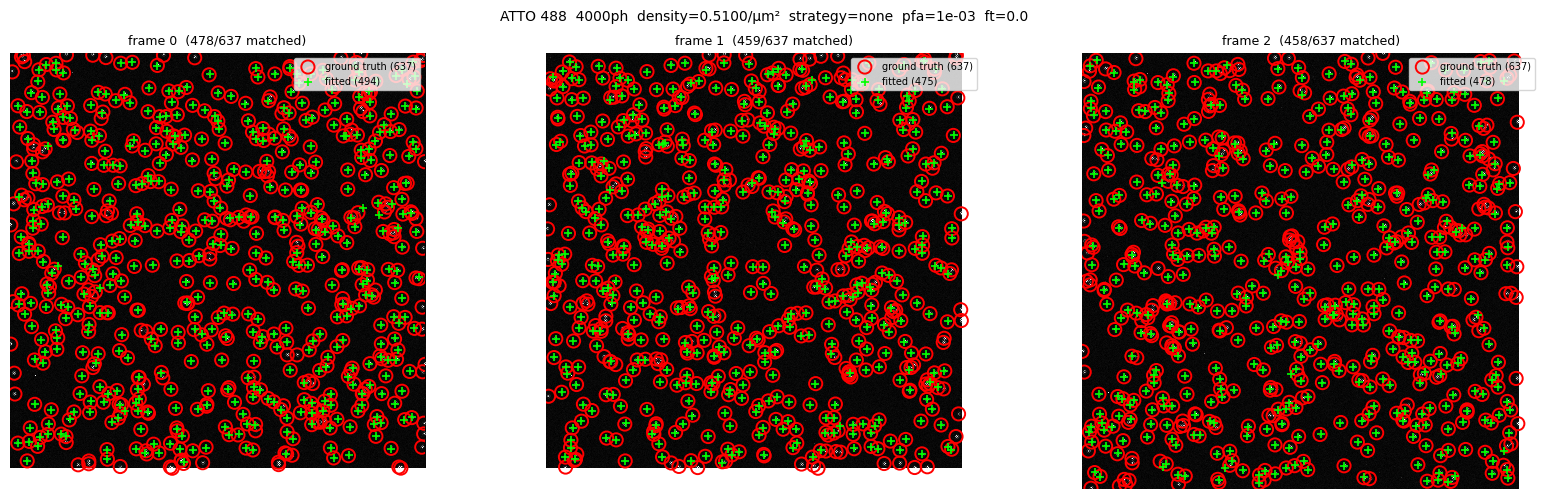

In [21]:
# ── Sanity check: overlay fits vs ground truth for one condition ──────────────
DIAG_DYE            = dyes[0]
DIAG_N_PHOTON        = n_photon_levels[1]      # mid photon level (4000)
DIAG_D_IDX           = len(density_space) // 2  # mid density
DIAG_STRATEGY        = 'none'                    # no demosaicing
DIAG_PFA             = 1e-3
DIAG_FT              = 0.0
DIAG_N_FRAMES_SHOW   = 3

dye_str  = DIAG_DYE.replace(' ', '_')
sigma_px = dye_params[DIAG_DYE]['sigma_px']
ph_dir   = save_root / dye_str / f'{DIAG_N_PHOTON}ph'
density  = density_space[DIAG_D_IDX]
stem     = f'd{DIAG_D_IDX:02d}_density{density:.4f}'

tif_path = ph_dir / f'{stem}_images.tif'
gt_path  = ph_dir / f'{stem}_gt.csv'
h5_path  = ph_dir / f'{stem}_{condition_tag(DIAG_STRATEGY, DIAG_PFA, DIAG_FT)}.h5'

print(f'Diagnostic condition: {DIAG_DYE}  {DIAG_N_PHOTON}ph  d{DIAG_D_IDX:02d}  '
      f'density={density:.4f}/µm²  strategy={DIAG_STRATEGY}  pfa={DIAG_PFA:.0e}  '
      f'fraction_true={DIAG_FT}')

if not (tif_path.exists() and gt_path.exists() and h5_path.exists()):
    print('Missing one or more required files -- run the generation/fitting loops above first.')
else:
    gt_df   = pd.read_csv(gt_path)
    locs_df = IO.read_h5_database(str(h5_path))
    print(f'{len(gt_df)} ground-truth rows, {len(locs_df)} fitted localisations')

    # Whole-condition (all frames) metrics, using the SAME compute_metrics used below.
    m = compute_metrics(gt_df, locs_df, match_mode, match_multiplier, sigma_px)
    print(f"Whole-condition metrics: tp={m['tp']}  fp={m['fp']}  fn={m['fn']}  "
          f"jaccard={m['jaccard']:.3f}  ppv={m['ppv']:.3f}  recall={m['recall']:.3f}")

    with tifffile.TiffFile(tif_path) as tif:
        n_frames_available = len(tif.pages)
        show_frames = list(range(min(DIAG_N_FRAMES_SHOW, n_frames_available)))
        frames_raw  = [tif.pages[f].asarray() for f in show_frames]

    fig, axs = plt.subplots(1, len(show_frames), figsize=(5.5 * len(show_frames), 5))
    if len(show_frames) == 1:
        axs = [axs]

    radius = match_multiplier * sigma_px
    for ax, f in zip(axs, show_frames):
        frame_img = frames_raw[f]
        vmin, vmax = np.percentile(frame_img, [0.1, 99.9])
        ax.imshow(frame_img, cmap='gray', vmin=vmin, vmax=vmax, origin='upper', interpolation='nearest')

        gt_frame  = gt_df[gt_df['frame_idx'] == f]
        loc_frame = locs_df[locs_df['frame'] == f]

        # Axis-swap note (see compute_metrics's docstring): gt's (y_px, x_px) pair
        # lines up with the image's (col, row) = (horizontal, vertical), matching
        # (xc, yc) directly -- so no swap is needed for the fitted points here.
        ax.scatter(gt_frame['y_px'], gt_frame['x_px'], s=90, facecolors='none',
                   edgecolors='red', linewidths=1.4, label=f'ground truth ({len(gt_frame)})')
        ax.scatter(loc_frame['xc'], loc_frame['yc'], s=40, marker='+', color='lime',
                   linewidths=1.2, label=f'fitted ({len(loc_frame)})')

        # Per-frame match count for this displayed frame, as a quick visual/numeric cross-check
        if len(gt_frame) and len(loc_frame):
            gt_xy    = gt_frame[['y_px', 'x_px']].values
            loc_xy   = loc_frame[['xc', 'yc']].values
            dist_mat = cdist(loc_xy, gt_xy)
            cost     = dist_mat.copy()
            cost[cost > radius] = 1e9
            row_ind, col_ind = linear_sum_assignment(cost)
            valid   = dist_mat[row_ind, col_ind] <= radius
            n_match = int(valid.sum())
        else:
            n_match = 0

        ax.set_title(f'frame {f}  ({n_match}/{len(gt_frame)} matched)', fontsize=9)
        ax.legend(loc='upper right', fontsize=7)
        ax.axis('off')

    fig.suptitle(
        f'{DIAG_DYE}  {DIAG_N_PHOTON}ph  density={density:.4f}/µm²  '
        f'strategy={DIAG_STRATEGY}  pfa={DIAG_PFA:.0e}  ft={DIAG_FT}',
        fontsize=10,
    )
    fig.tight_layout()
    plt.show()

In [18]:
# ── Metrics loop ───────────────────────────────────────────────────────────────
# Iterates the SAME (strategy, pfa, fraction_true) grid as the fitting loop
# above (DEMOSAIC_STRATEGIES / pfa_conditions / FRACTION_TRUE_CONDITIONS /
# condition_tag), so metrics_df/Metrics_XR can be sliced/plotted against any of
# them. Uses compute_metrics defined above (with the x/y axis-swap fix).
import xarray as xr

metric_names = ['jaccard', 'ppv', 'recall', 'fp_rate', 'missed', 'tp', 'fp', 'fn', 'n_gt', 'n_det']

Metrics_XR = xr.DataArray(
    data=np.full(
        [len(dyes), len(n_photon_levels), len(density_space),
         len(DEMOSAIC_STRATEGIES), len(pfa_conditions), len(FRACTION_TRUE_CONDITIONS),
         len(metric_names)],
        np.nan,
    ),
    coords={
        'dye': dyes, 'n_photon': n_photon_levels, 'density': density_space,
        'strategy': DEMOSAIC_STRATEGIES, 'pfa': pfa_conditions,
        'fraction_true': FRACTION_TRUE_CONDITIONS, 'metric': metric_names,
    },
    dims=['dye', 'n_photon', 'density', 'strategy', 'pfa', 'fraction_true', 'metric'],
)

rows    = []
n_total = (len(dyes) * len(n_photon_levels) * len(density_space)
           * len(DEMOSAIC_STRATEGIES) * len(pfa_conditions) * len(FRACTION_TRUE_CONDITIONS))
i_cond  = 0

for i_dye, dye in enumerate(dyes):
    dye_str  = dye.replace(' ', '_')
    sigma_px = dye_params[dye]['sigma_px']

    for i_photon, n_photon in enumerate(n_photon_levels):
        ph_dir = save_root / dye_str / f'{n_photon}ph'

        for d_idx, density in enumerate(density_space):
            stem  = f'd{d_idx:02d}_density{density:.4f}'
            gt_df = pd.read_csv(ph_dir / f'{stem}_gt.csv')

            for i_strat, strategy in enumerate(DEMOSAIC_STRATEGIES):
                for i_pfa, pfa in enumerate(pfa_conditions):
                    for i_ft, ft in enumerate(FRACTION_TRUE_CONDITIONS):
                        i_cond += 1
                        h5_path = ph_dir / f'{stem}_{condition_tag(strategy, pfa, ft)}.h5'
                        if not h5_path.exists():
                            print(f'  Missing: {h5_path.name}'); continue

                        locs_df = IO.read_h5_database(str(h5_path))
                        m = compute_metrics(gt_df, locs_df, match_mode, match_multiplier, sigma_px)

                        rows.append(dict(
                            dye=dye, n_photon=n_photon, density=density, d_idx=d_idx,
                            strategy=strategy, pfa=pfa, fraction_true=ft, **m,
                        ))
                        Metrics_XR.values[i_dye, i_photon, d_idx, i_strat, i_pfa, i_ft, :] = [
                            m[name] for name in metric_names
                        ]
                        if i_cond % 240 == 0 or i_cond == n_total:
                            print(f'[{i_cond:6d}/{n_total}] {dye}  {n_photon}ph  d{d_idx:02d}  '
                                  f'{strategy}  pfa={pfa:.0e}  ft={ft:.2f}  J={m["jaccard"]:.3f}  '
                                  f'ppv={m["ppv"]:.3f}  recall={m["recall"]:.3f}')

metrics_df = pd.DataFrame(rows)
metrics_df['pfa_label'] = metrics_df['pfa'].map({1e-3: 'pfa=10⁻³', 1e-4: 'pfa=10⁻⁴'})
print(f'\nMetrics ready: {len(metrics_df)} rows')
print(metrics_df[['dye', 'n_photon', 'density', 'strategy', 'pfa', 'fraction_true',
                   'jaccard', 'ppv', 'recall']].head())

metrics_nc_path = save_root / 'emitter_density_metrics.nc'
Metrics_XR.to_netcdf(metrics_nc_path)
print(f'Saved xarray metrics → {metrics_nc_path}')

[   240/3600] ATTO 488  4000ph  d19  none  pfa=1e-04  ft=0.00  J=0.838  ppv=0.983  recall=0.851
[   480/3600] ATTO 488  10000ph  d39  none  pfa=1e-04  ft=0.00  J=0.741  ppv=0.963  recall=0.762
[   720/3600] ATTO 565  1000ph  d59  none  pfa=1e-04  ft=0.00  J=0.463  ppv=0.987  recall=0.466
[   960/3600] ATTO 565  4000ph  d79  none  pfa=1e-04  ft=0.00  J=0.490  ppv=0.972  recall=0.497
[  1200/3600] ATTO 565  10000ph  d99  none  pfa=1e-04  ft=0.00  J=0.401  ppv=0.957  recall=0.408
[  1440/3600] ATTO 647N  4000ph  d19  none  pfa=1e-04  ft=0.00  J=0.811  ppv=0.995  recall=0.814
[  1680/3600] ATTO 647N  10000ph  d39  none  pfa=1e-04  ft=0.00  J=0.680  ppv=0.988  recall=0.686
[  1920/3600] synthetic_ATTO488  1000ph  d59  none  pfa=1e-04  ft=0.00  J=0.733  ppv=0.998  recall=0.734
[  2160/3600] synthetic_ATTO488  4000ph  d79  none  pfa=1e-04  ft=0.00  J=0.665  ppv=0.997  recall=0.666
[  2400/3600] synthetic_ATTO488  10000ph  d99  none  pfa=1e-04  ft=0.00  J=0.588  ppv=0.996  recall=0.589
[  2640

## Figure: Jaccard Index + Recall vs Density

Columns = photon level; solid lines = pfa=10⁻³; dashed = pfa=10⁻⁴; colours = dye.

In [19]:
Metrics_XR

<xarray.DataArray (dye: 6, n_photon: 3, density: 100, strategy: 1, pfa: 2,
                   fraction_true: 1, metric: 10)> Size: 288kB
array([[[[[[[  6.98264019e-01,   7.35851540e-01,   9.31833333e-01, ...,
               8.18000000e+02,   1.20000000e+04,   1.51960000e+04]],

           [[  8.90183559e-01,   9.54638822e-01,   9.29500000e-01, ...,
               8.46000000e+02,   1.20000000e+04,   1.16840000e+04]]]],



         [[[[  7.98974923e-01,   8.50868195e-01,   9.29080000e-01, ...,
               1.77300000e+03,   2.50000000e+04,   2.72980000e+04]],

           [[  9.05204751e-01,   9.75082078e-01,   9.26640000e-01, ...,
               1.83400000e+03,   2.50000000e+04,   2.37580000e+04]]]],



         [[[[  8.34704068e-01,   8.98458701e-01,   9.21648649e-01, ...,
               2.89900000e+03,   3.70000000e+04,   3.79550000e+04]],

           [[  9.04727679e-01,   9.83619367e-01,   9.18567568e-01, ...,
...
               6.25443000e+05,   1.22300000e+06,   5.97625000e+05]],

           [[  3.84471232e-01,   9.99874545e-01,   3.84489779e-01, ...,
               7.52769000e+05,   1.22300000e+06,   4.70290000e+05]]]],



         [[[[  4.83386917e-01,   9.99876166e-01,   4.83415858e-01, ...,
               6.38498000e+05,   1.23600000e+06,   5.97576000e+05]],

           [[  3.78911584e-01,   9.99846296e-01,   3.78933657e-01, ...,
               7.67638000e+05,   1.23600000e+06,   4.68434000e+05]]]],



         [[[[  4.79261680e-01,   9.99872959e-01,   4.79290865e-01, ...,
               6.49845000e+05,   1.24800000e+06,   5.98231000e+05]],

           [[  3.74356501e-01,   9.99873737e-01,   3.74374199e-01, ...,
               7.80781000e+05,   1.24800000e+06,   4.67278000e+05]]]]]]])
Coordinates:
  * dye            (dye) <U18 432B 'ATTO 488' ... 'synthetic_ATTO647N'
  * n_photon       (n_photon) int64 24B 1000 4000 10000
  * density        (density) float64 800B 0.01 0.02 0.03 0.04 ... 0.98 0.99 1.0
  * strategy       (strategy) <U4 16B 'none'
  * pfa            (pfa) float64 16B 0.001 0.0001
  * fraction_true  (fraction_true) float64 8B 0.0
  * metric         (metric) <U7 280B 'jaccard' 'ppv' 'recall' ... 'n_gt' 'n_det'

In [24]:
Metrics_XR

<xarray.DataArray 'metric' (metric: 10)> Size: 280B
array(['jaccard', 'ppv', 'recall', 'fp_rate', 'missed', 'tp', 'fp', 'fn',
       'n_gt', 'n_det'],
      dtype='<U7')
Coordinates:
  * metric   (metric) <U7 280B 'jaccard' 'ppv' 'recall' ... 'fn' 'n_gt' 'n_det'

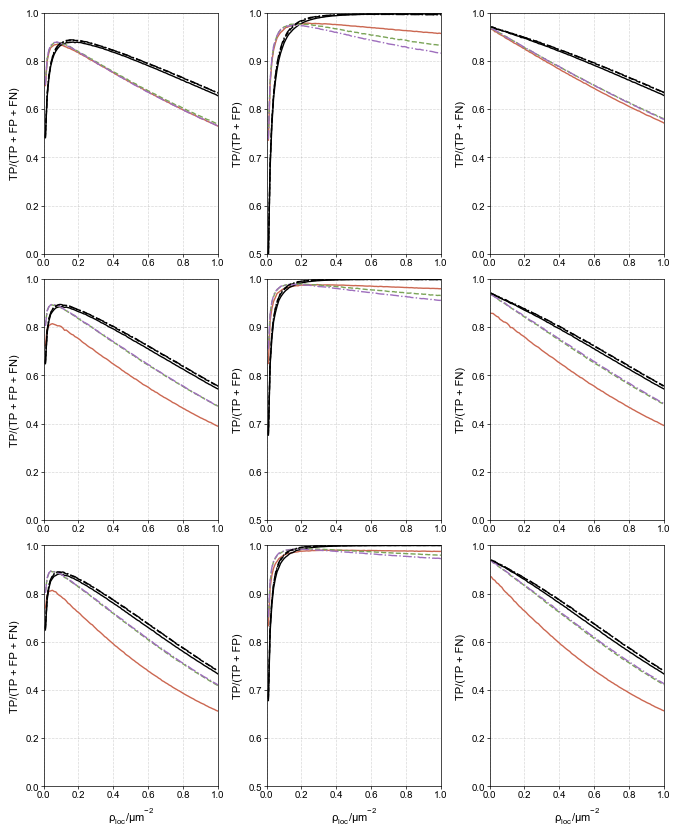

In [30]:
fig, axs = plotter.two_column_plot(ncols=3, nrows=3)

# jaccard, ppv, recall
photoncolour = ["#cb6751",
"#7aa457",
"#9e6ebd"]
ls = ['-', '--', '-.']
metrics = ['TP/(TP + FP + FN)', 'TP/(TP + FP)', 'TP/(TP + FN)']
for metric in np.arange(3):
    for dye in np.arange(3):
        for photon in np.arange(3):
            axs[dye, metric] = plotter.line_plot(axs[dye, metric], density_space, Metrics_XR[dye, photon, :, 0, 0, 0, metric],
                                                linestyle=ls[photon], color=photoncolour[photon], ylabel=metrics[metric])
            axs[dye, metric] = plotter.line_plot(axs[dye, metric], density_space, Metrics_XR[dye+3, photon, :, 0, 0, 0, metric],
                                    linestyle=ls[photon], color='black', ylabel=metrics[metric])

            axs[dye, metric].set_xlim([0, 1])
            if metric == 1:
                axs[dye, metric].set_ylim([0.5, 1])
            else:
                axs[dye, metric].set_ylim([0, 1])
            if dye == 2:
                axs[dye, metric].set_xlabel(r'$\mathrm{\rho}_\mathrm{loc}$/$\mathrm{\mu}$m$^{-2}$')
            else:
                axs[dye, metric].set_xlabel('')
figure_root = Path('/scratch/sycamore-asap/2026_Multicolour_Paper/For_Paper')
fig.savefig(figure_root / 'density_metrics_plot.svg', dpi=600, format='svg')
plt.show()


## Ridgeplot: Spectral Channel Distributions vs Density

For a chosen photon level and pfa, show how the B/G/R channel-fraction distributions (after photon normalisation) shift and broaden as emitter density increases.  Each horizontal "ridge" is one density level; ridges stack from low density (bottom) to high density (top).

SyntaxError: keyword argument repeated: xy (113078584.py, line 85)

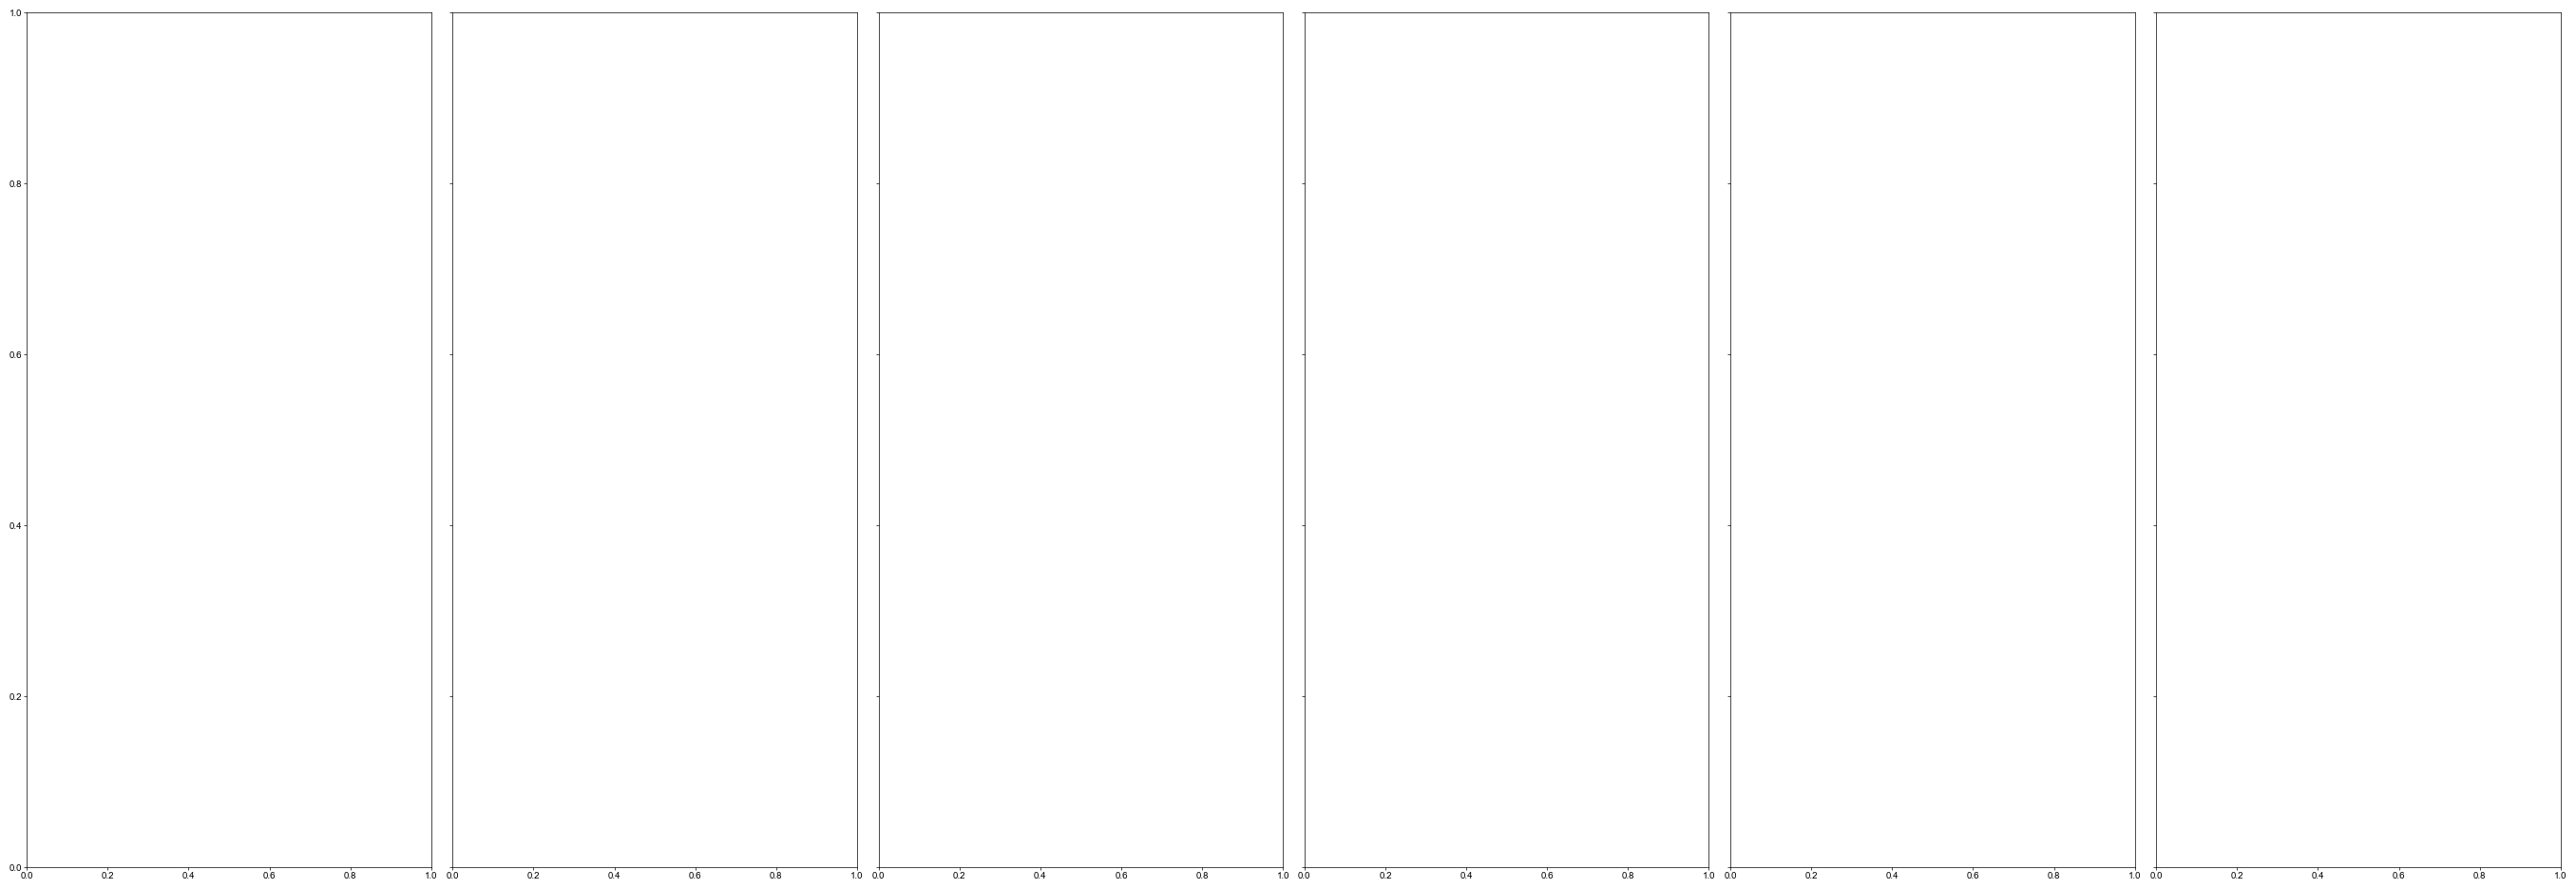

In [31]:

# ── Ridgeplot: B/G/R spectral fractions vs emitter density ────────────────────
from scipy.stats import gaussian_kde
import matplotlib.patches as mpatches

ridge_n_photon = 4000   # photon level to display (adjust as needed)
ridge_pfa      = 1e-3   # pfa condition to display
n_ridges       = 15     # number of density levels to show as ridges

ridge_idx       = np.round(np.linspace(0, len(density_space) - 1, n_ridges)).astype(int)
ridge_densities = density_space[ridge_idx]

ch_names  = ['A_B', 'A_G', 'A_R']
ch_colors = ['royalblue', 'seagreen', 'firebrick']
ch_labels = ['Blue', 'Green', 'Red']
tag       = pfa_tag(ridge_pfa)

row_height = 1.0    # vertical spacing between ridge baselines
kde_height = 1.4    # max height a KDE curve can reach above its baseline
x_vals     = np.linspace(-0.02, 1.02, 400)

fig, axes = plt.subplots(1, len(dyes), figsize=(4.5 * len(dyes), 1.0 + n_ridges * 0.55),
                         sharey=True)

for col, dye in enumerate(dyes):
    ax      = axes[col]
    dye_str = dye.replace(' ', '_')
    ph_dir  = save_root / dye_str / f'{ridge_n_photon}ph'

    # Draw ridges bottom → top so higher densities paint over lower ones
    for i, (d_idx, density) in enumerate(zip(ridge_idx, ridge_densities)):
        stem    = f'd{d_idx:02d}_density{density:.4f}'
        h5_path = ph_dir / f'{stem}_{tag}.h5'
        y_base  = i * row_height

        # White base strip: hides tails of ridge below and gives a clean baseline
        ax.fill_between(x_vals,
                        y_base - row_height * 0.15, y_base,
                        color='white', lw=0, zorder=3 * i)
        ax.axhline(y_base, color='#cccccc', lw=0.4, zorder=3 * i + 0.5)

        if not h5_path.exists():
            continue
        locs = IO.read_h5_database(str(h5_path))
        if len(locs) < 10:
            continue

        for ch, color in zip(ch_names, ch_colors):
            vals = locs[ch].dropna().values
            if len(vals) < 10:
                continue
            try:
                kde   = gaussian_kde(vals, bw_method=0.08)
                kde_y = kde(x_vals)
                # Normalise so the tallest curve reaches kde_height above baseline
                kde_y = kde_y / kde_y.max() * kde_height
            except Exception:
                continue

            ax.fill_between(x_vals, y_base, y_base + kde_y,
                            color=color, alpha=0.30, lw=0, zorder=3 * i + 1)
            ax.plot(x_vals, y_base + kde_y,
                    color=color, lw=0.9, alpha=0.85, zorder=3 * i + 2)

        # Density label flush right
        ax.text(1.03, y_base + 0.05 * row_height,
                f'{density:.3f}', va='bottom', ha='left',
                fontsize=5.5, color='#555555', zorder=3 * i + 3)

    top_y = (n_ridges - 1) * row_height + kde_height + 0.3
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.35, top_y)
    ax.set_xlabel('Channel fraction', fontsize=9)
    ax.set_title(dye, fontsize=9, pad=5)
    ax.set_yticks([])
    for spine in ['left', 'right', 'top']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_linewidth(0.5)

    # Density direction arrow on the left of the first column
    if col == 0:
        ax.annotate('', xy=(0, top_y - 0.2), xytext=(0, 0),
                    xycoords='data', textcoords='data',
                    arrowprops=dict(arrowstyle='->', color='#444', lw=1.0),
                    annotation_clip=False,
                    xytext=(-0.14, 0.02), xy=(-0.14, top_y - 0.3),
                    )
        ax.text(-0.20, top_y / 2, 'Density\n(µm⁻²)',
                ha='center', va='center', fontsize=7, color='#444',
                rotation=90, transform=ax.transData)

# Shared channel legend
patches = [mpatches.Patch(facecolor=c, alpha=0.6, label=l)
           for c, l in zip(ch_colors, ch_labels)]
axes[-1].legend(handles=patches, loc='upper right', fontsize=7.5,
                framealpha=0.85, edgecolor='#ccc', handlelength=1.2)

fig.suptitle(
    f'Spectral channel fractions vs emitter density  '
    f'({ridge_n_photon:,} ph · pfa={ridge_pfa:.0e})',
    fontsize=10, y=1.01,
)
figure_root = Path('/scratch/sycamore-asap/2026_Multicolour_Paper/For_Paper')
fig.savefig(figure_root / 'spectral_ridge_plots.svg', dpi=600, format='svg')
plt.show()
